
=== RUTAS ENCONTRADAS POR CADA ALGORITMO ===
Greedy Search:    Plaza → Parque → Mirador → Catedral
A* Search:        Plaza → Museo → Mirador → Catedral
Weighted A*:      Plaza → Parque → Mirador → Catedral
IDA* Search:      Plaza → Museo → Mirador → Catedral
RBFS Search:      Plaza → Museo → Mirador → Catedral

GIFs generados y mostrados en pantalla:


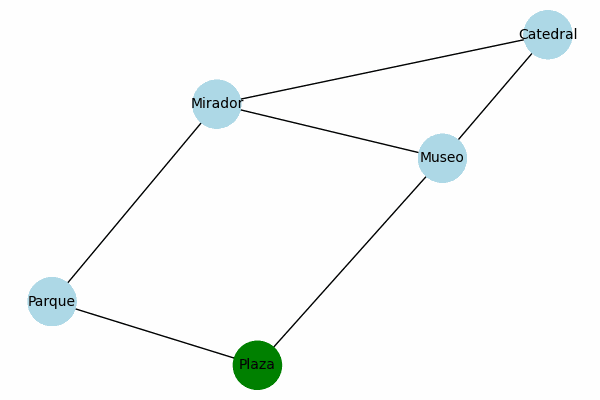

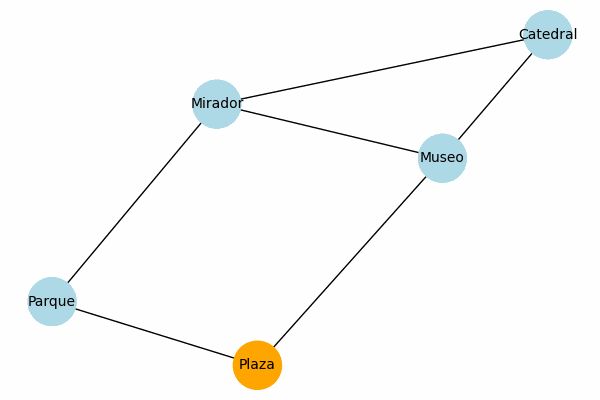

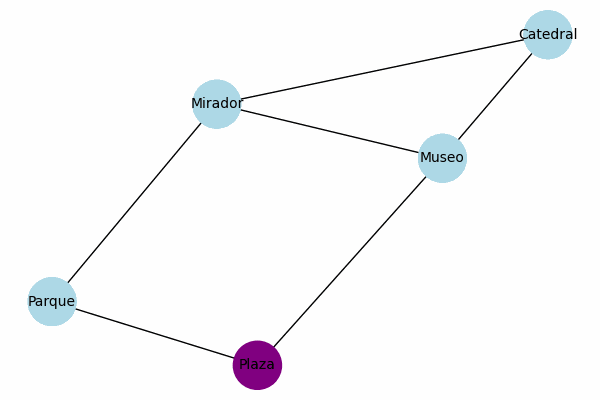

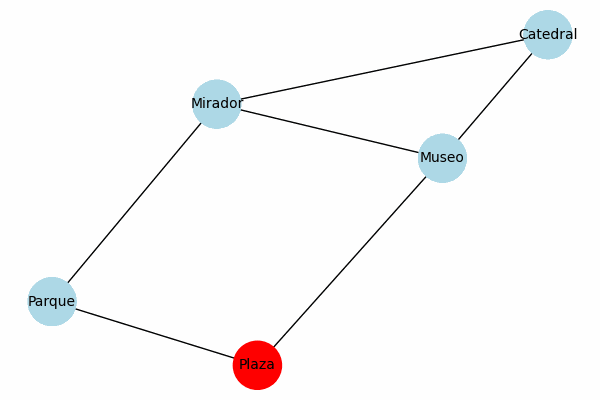

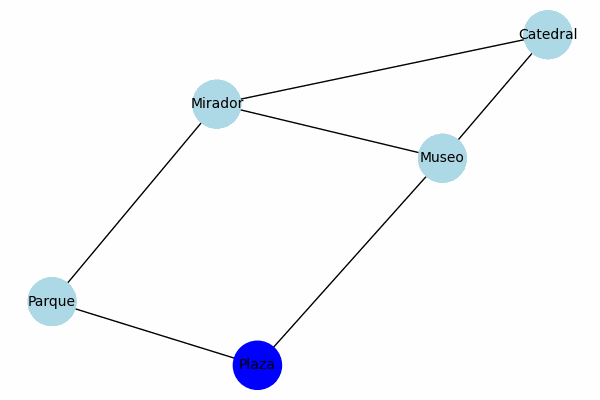

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import heapq
import math
from IPython.display import Image, display

# --- Grafo ---
G = nx.Graph()
edges = [
    ("Plaza", "Museo", 2),
    ("Plaza", "Parque", 4),
    ("Museo", "Mirador", 3),
    ("Museo", "Catedral", 6),
    ("Parque", "Mirador", 2),
    ("Mirador", "Catedral", 1)
]
G.add_weighted_edges_from(edges)

# --- Heurística ---
heuristic = {
    "Plaza": 7,
    "Museo": 6,
    "Parque": 4,
    "Mirador": 1,
    "Catedral": 0
}

pos = nx.spring_layout(G, seed=42)

# ================== ALGORITMOS ==================

# --- Greedy Search ---
def greedy_search(start, goal):
    visited = []
    frontier = [(heuristic[start], start)]
    while frontier:
        _, node = heapq.heappop(frontier)
        if node in visited:
            continue
        visited.append(node)
        if node == goal:
            break
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                heapq.heappush(frontier, (heuristic[neighbor], neighbor))
    return visited

# --- A* Search ---
def astar_search(start, goal):
    visited = []
    g_score = {n: float('inf') for n in G.nodes()}
    g_score[start] = 0
    frontier = [(heuristic[start], start)]
    while frontier:
        _, node = heapq.heappop(frontier)
        if node in visited:
            continue
        visited.append(node)
        if node == goal:
            break
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                cost = g_score[node] + G[node][neighbor]['weight']
                if cost < g_score[neighbor]:
                    g_score[neighbor] = cost
                    f = cost + heuristic[neighbor]
                    heapq.heappush(frontier, (f, neighbor))
    return visited

# --- Weighted A* ---
def weighted_astar_search(start, goal, w=1.5):                     # Algoritmo Weighted A*, recibe inicio, meta y peso w
    visited = []                                                    # Lista para registrar el orden de nodos visitados
    g_score = {n: float('inf') for n in G.nodes()}                 # Inicializa costos acumulados (g) con infinito
    g_score[start] = 0                                             # Costo inicial del nodo de partida = 0
    frontier = [(heuristic[start] * w, start)]                     # Cola de prioridad con (f = h * w, nodo)

    while frontier:                                                # Mientras haya nodos en la frontera
        _, node = heapq.heappop(frontier)                          # Extrae el nodo con menor f
        if node in visited:                                        # Si ya fue visitado, lo ignora
            continue
        visited.append(node)                                       # Marca nodo como visitado
        if node == goal:                                           # Si llegamos a la meta, detenemos búsqueda
            break

        for neighbor in G.neighbors(node):                         # Recorremos cada vecino del nodo actual
            if neighbor not in visited:                            # Solo expandir si no fue visitado
                cost = g_score[node] + G[node][neighbor]['weight'] # Calcula g(n) acumulado
                if cost < g_score[neighbor]:                       # Si encontramos un mejor costo
                    g_score[neighbor] = cost                       # Actualizamos el g_score
                    f = cost + w * heuristic[neighbor]             # f(n) = g(n) + w * h(n)
                    heapq.heappush(frontier, (f, neighbor))        # Añadimos vecino a la frontera
    return visited                                                 # Devuelve el orden de visitados


# --- IDA* ---
def idastar_search(start, goal):                                   # Algoritmo IDA* (Iterative Deepening A*)
    visited_order = []                                             # Lista para registrar nodos visitados en orden
    visited_set = set()                                            # Conjunto para evitar repetidos

    def search(node, g, bound, path):                              # Función recursiva: nodo, costo g, límite, camino actual
        f = g + heuristic[node]                                    # f = g(n) + h(n)
        if f > bound:                                              # Si f excede el límite actual, cortar rama
            return f
        if node not in visited_set:                                # Si nodo no se había registrado
            visited_set.add(node)
            visited_order.append(node)                             # Se añade al orden de visita
        if node == goal:                                           # Si llegamos a la meta
            return "FOUND"

        min_bound = math.inf                                       # Límite mínimo para la próxima iteración
        for nbr in G.neighbors(node):                              # Expandir vecinos
            if nbr in path:                                        # Evitar ciclos
                continue
            t = search(nbr, g + G[node][nbr]['weight'], bound, path | {nbr})  # Llamada recursiva con costo acumulado
            if t == "FOUND":                                       # Si encontramos la meta
                return "FOUND"
            if t < min_bound:                                      # Actualizar nuevo límite mínimo
                min_bound = t
        return min_bound                                           # Retorna el mejor límite encontrado

    bound = heuristic[start]                                       # Límite inicial = h(n) del inicio
    while True:                                                    # Iterar incrementando límite hasta encontrar meta
        t = search(start, 0, bound, {start})                       # Llamada inicial
        if t == "FOUND":                                           # Si encontramos meta, terminamos
            break
        if t == math.inf:                                          # Si no hay solución, salir
            break
        bound = t                                                  # Ajustar límite con el mejor encontrado
    return visited_order                                           # Devuelve nodos visitados


# --- RBFS ---
def rbfs_search(start, goal):                                      # Algoritmo Recursive Best-First Search (RBFS)
    visited_order, visited_set = [], set()                         # Lista y conjunto para nodos visitados

    def rbfs(node, g, f_limit, path):                              # Función recursiva: nodo, costo g, límite, camino
        f_node = g + heuristic[node]                               # Calcula f(n) para el nodo actual
        if node not in visited_set:                                # Si no está visitado
            visited_set.add(node)
            visited_order.append(node)                             # Registrar en el orden de visita
        if node == goal:                                           # Si encontramos meta
            return True, f_node

        successors = []                                            # Lista de sucesores (nodo, g, f)
        for nbr in G.neighbors(node):                              # Generar sucesores
            if nbr in path:                                        # Evitar ciclos
                continue
            g2 = g + G[node][nbr]['weight']                        # Nuevo g(n)
            f2 = max(g2 + heuristic[nbr], f_node)                  # f(n) corregido (consistencia)
            successors.append([nbr, g2, f2])                       # Añadir sucesor

        if not successors:                                         # Si no hay sucesores, camino muerto
            return False, math.inf

        while True:                                                # Ciclo hasta encontrar solución o agotar límite
            successors.sort(key=lambda x: x[2])                    # Ordenar por f más bajo
            best = successors[0]                                   # Mejor sucesor
            if best[2] > f_limit:                                  # Si f excede el límite, retrocedemos
                return False, best[2]
            alternative = successors[1][2] if len(successors) > 1 else math.inf  # Segundo mejor f
            result, new_f = rbfs(best[0], best[1], min(f_limit, alternative), path | {best[0]})  # Recursión
            best[2] = new_f                                        # Actualizamos el f del mejor sucesor
            if result:                                             # Si encontró solución, devolvemos True
                return True, new_f

    rbfs(start, 0, math.inf, {start})                              # Llamada inicial
    return visited_order                                           # Devuelve nodos visitados en orden


# ================== FUNCIÓN PARA CREAR GIFS ==================
def build_gif(visit_order, highlight_color, prefix, title_prefix):
    frames = []
    for i in range(1, len(visit_order)+1):                              # Itera sobre cada paso visitado
        plt.figure(figsize=(6, 4))
        # Colores: nodos ya visitados en highlight_color, otros en azul claro
        node_colors = [highlight_color if n in visit_order[:i] else "lightblue" for n in G.nodes()]
        nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=1200, font_size=10)

        if i < len(visit_order):                                        # Frames intermedios: mostrar paso actual
            plt.title(f"{title_prefix} {i}: {visit_order[i-1]}")
        else:                                                           # Último frame: mostrar ruta completa
            full_route = " → ".join(visit_order)
            plt.title(f"{title_prefix}\nRuta completa: {full_route}", fontsize=11)

        filename = f"{prefix}_{i}.png"                                  # Nombre del archivo para cada frame
        plt.savefig(filename)
        frames.append(imageio.imread(filename))
        plt.close()

    out_gif = f"{prefix}_search.gif"                                    # Nombre del GIF final
    imageio.mimsave(out_gif, frames, duration=1)                        # Crea el GIF
    display(Image(filename=out_gif))                                    # Muestra el GIF

# ================== EJECUTAR Y MOSTRAR TODOS ==================
greedy_path = greedy_search("Plaza", "Catedral")
astar_path = astar_search("Plaza", "Catedral")
weighted_path = weighted_astar_search("Plaza", "Catedral", w=1.5)
idastar_path = idastar_search("Plaza", "Catedral")
rbfs_path = rbfs_search("Plaza", "Catedral")

# --- Mostrar rutas en consola ---
print("\n=== RUTAS ENCONTRADAS POR CADA ALGORITMO ===")
print(f"Greedy Search:    {' → '.join(greedy_path)}")
print(f"A* Search:        {' → '.join(astar_path)}")
print(f"Weighted A*:      {' → '.join(weighted_path)}")
print(f"IDA* Search:      {' → '.join(idastar_path)}")
print(f"RBFS Search:      {' → '.join(rbfs_path)}")

# --- Generar GIFs ---
print("\nGIFs generados y mostrados en pantalla:")
build_gif(greedy_path, "green", "greedy", "Greedy Search")
build_gif(astar_path, "orange", "astar", "A* Search")
build_gif(weighted_path, "purple", "weighted", "Weighted A* Search")
build_gif(idastar_path, "red", "idastar", "IDA* Search")
build_gif(rbfs_path, "blue", "rbfs", "RBFS Search")
